![Logo Curso](../assets/LogoCurso_gemini.png)

# MÓDULO 08: Visualización de Datos Científicos con Matplotlib y Pandas

**Curso:** Python para Ciencia Abierta (CSIC)  
**Autor:** Gustavo Liñán Cembrano  
**Fechas:** 5 a 8 de Octubre de 2026  
**Tiempo Estimado de Impartición:** 1 hora  
**Módulo:** 08 - Scientific Data Visualization, Matplotlib Architecture, Figure & Axes, Subplots & Pandas Plotting  

---

## 1. Objetivos de Aprendizaje

- **Arquitectura de Matplotlib:** Comprender los componentes clave de una gráfico en Matplotlib (`Figure`, `Axes`, `Axis`, `Ticks`, `Labels`, `Legend`, `Grid`).
- **Interfaces de Programación:** Dominar la diferencia pedagógica entre la interfaz funcional tipo MATLAB (`plt.plot()`) y la **interfaz orientada a objetos (`fig, ax = plt.subplots()`)**, recomendada para publicaciones científicas de alta calidad.
- **Tipología de Gráficos Científicos:**
  - **Gráficos de Líneas (`plot`):** Representación de tendencias y series temporales.
  - **Gráficos de Barras (`bar` / `barh`):** Comparación de categorías y frecuencias absolutas/relativas.
  - **Gráficos de Dispersión (`scatter`):** Análisis de correlación entre dos variables continuas con codificación de color (`cmap`) y tamaño de marcador.
  - **Histogramas y Diagramas de Caja (`hist` / `boxplot`):** Diagnóstico de distribuciones y detección de valores atípicos (*outliers*).
- **Integración Nativa con Pandas:** Generar figuras directamente a partir de DataFrames y Series (`df.plot()`).
- **Composición Multi-Panel:** Diseñar figuras compuestas (*Subplots*) estructuradas para artículos científicos usando `plt.subplots()` y `subplot2grid()`.
- **Exportación de Alta Calidad para Ciencia Abierta:** Guardar figuras en formatos rasterizados de alta resolución (`PNG` a 300 DPI) y vectoriales (`PDF`/`SVG`) listos para publicación.


## 2. Configuración del Entorno e Importación de Módulos

Importamos las librerías estándar para análisis numérico y gráfico (`matplotlib.pyplot`, `pandas`, `numpy`), y configuramos la importación del paquete personalizado `lib` para reutilizar nuestras funciones auxiliares como `linea()`.


In [1]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Ignorar advertencias no críticas para mantener limpia la salida
warnings.filterwarnings('ignore')


In [2]:
# Añadir el directorio raíz del proyecto a sys.path para acceder al paquete lib/
root_path = os.path.abspath("..") if os.path.exists("../lib") else os.path.abspath(".")
if root_path not in sys.path:
    sys.path.append(root_path)

import lib.digital_csic as dcsic
from lib.mylib import linea as linea
# Ruta base flexible para el directorio DATASETS
datasets_dir = "../DATASETS" if os.path.exists("../DATASETS") else "DATASETS"
linea()
print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de Matplotlib: {matplotlib.__version__}")
print(f"Librería digital_csic cargada correctamente.")
print(f"Directorio de datos activo: {datasets_dir}")
linea()


****************************************************************************************************
Versión de Pandas: 3.0.5
Versión de Matplotlib: 3.11.1
Librería digital_csic cargada correctamente.
Directorio de datos activo: ../DATASETS
****************************************************************************************************


## 3. Anatomía de una Figura y la Interfaz Orientada a Objetos (`fig`, `ax`)

Matplotlib ofrece dos formas principales de construir gráficos:

1. **Interfaz Funcional (`pyplot` / estilo MATLAB):** Útil para gráficos rápidos mediante comandos globales como `plt.plot()`, `plt.title()`.
2. **Interfaz Orientada a Objetos (Recomendada para Investigación):** Separa explícitamente el lienzo contenedor (`Figure`) de los ejes gráficos (`Axes`). Permite control total sobre cada elemento gráfico.

### Conceptos Clave:
- **`Figure` (`fig`):** Es la ventana o lienzo completo que contiene una o más figuras.
- **`Axes` (`ax`):** Es la región del gráfico donde se dibujan los datos (ejes X e Y, título, leyendas y cuadrícula).


In [4]:
# Ejemplo 1: Estilo Funcional (plt.plot)
x = np.linspace(0, 10, 50) #Espacio lineal de 0 a 10 con 5000 puntos
y = x**2 * np.exp(-x**2)


In [3]:

Size = 4
LineSt = "--"
plt.figure(figsize=(5, 3)) #



<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

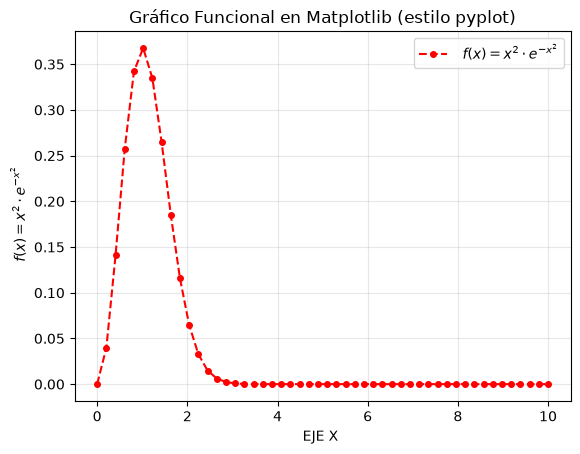

In [5]:

plt.plot(x, y, color='red', linestyle=LineSt, marker='o', markersize = Size, label=r" $f(x)=x^2 \cdot e^{-x^2}$")

#Observa como la etiqueta puede definirse en formato LaTeX
#El prefijo r viene de "Raw String" (cadena cruda o literal).
# Le indica a Python que trate las barras invertidas (\) 
# como texto literal plano, desactivando la interpretación 
# de caracteres de escape especiales (como \n para salto de 
# línea o \t para tabulación).


plt.title("Gráfico Funcional en Matplotlib (estilo pyplot)")
plt.xlabel("EJE X ")
plt.ylabel(r" $f(x)=x^2 \cdot e^{-x^2}$")
plt.grid(True, alpha=0.3)
plt.legend()




In [6]:

plt.show()

linea()


****************************************************************************************************


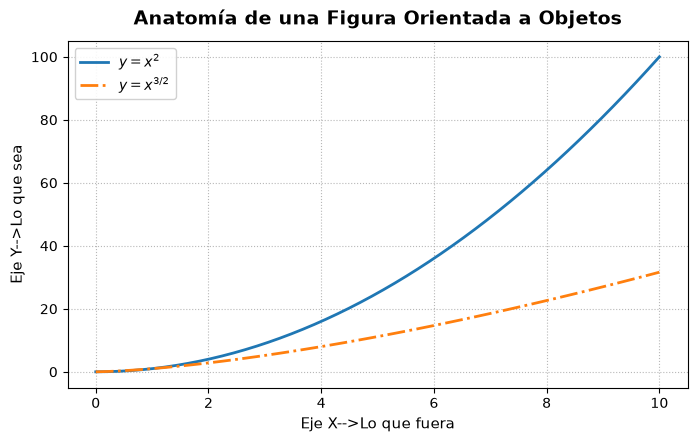

****************************************************************************************************


In [9]:
# Ejemplo 2: Estilo Orientado a Objetos (fig, ax) - Estándar Profesional
fig, ax = plt.subplots(figsize=(8, 4.5))
y=x**2
# Dibujar la curva principal
ax.plot(x, y, color='#1f77b4', linewidth=2, label=r'$y = x^2$')
y=(x**3)**(1/2)
ax.plot(x, y, color='#ff7f0e', linestyle='-.', linewidth=2, label=r'$y = x^{3/2}$')

# Personalización explícita mediante métodos de 'ax'
ax.set_title("Anatomía de una Figura Orientada a Objetos", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Eje X-->Lo que fuera", fontsize=11)
ax.set_ylabel("Eje Y-->Lo que sea", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.9)
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.show()
linea()


## 4. Tipología Principal de Gráficos para Ciencia Abierta

Exploraremos 4 tipos fundamentales de gráficos utilizados para comunicar evidencia científica:

- **4.1. Gráfico de Líneas (`ax.plot`):** Comparación de funciones continuas o series temporales.
- **4.2. Gráfico de Barras (`ax.bar` / `ax.barh`):** Frecuencias o magnitudes por categorías discretas.
- **4.3. Gráfico de Dispersión (`ax.scatter`):** Relación entre dos variables numéricas con dimensión adicional mediante escala de colores (`cmap`).
- **4.4. Histograma y Diagrama de Caja (`ax.hist` / `ax.boxplot`):** Evaluación de la distribución estadística y variabilidad de los datos.


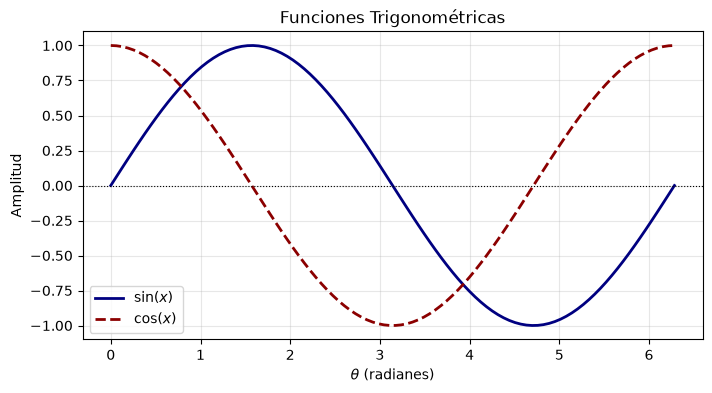

****************************************************************************************************


In [10]:
# 4.1. Gráficos de Líneas con Múltiples Series
x_vals = np.linspace(0, 2 * np.pi, 100)
seno = np.sin(x_vals)
coseno = np.cos(x_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, seno, label=r'$\sin(x)$', color='navy', linewidth=2)
ax.plot(x_vals, coseno, label=r'$\cos(x)$', color='darkred', linestyle='--', linewidth=2)

ax.set_title("Funciones Trigonométricas")
ax.set_xlabel("$\\theta$ (radianes)")
ax.set_ylabel("Amplitud")
ax.axhline(0, color='black', linewidth=0.8, linestyle=':') # Línea cero de referencia
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.show()
linea()


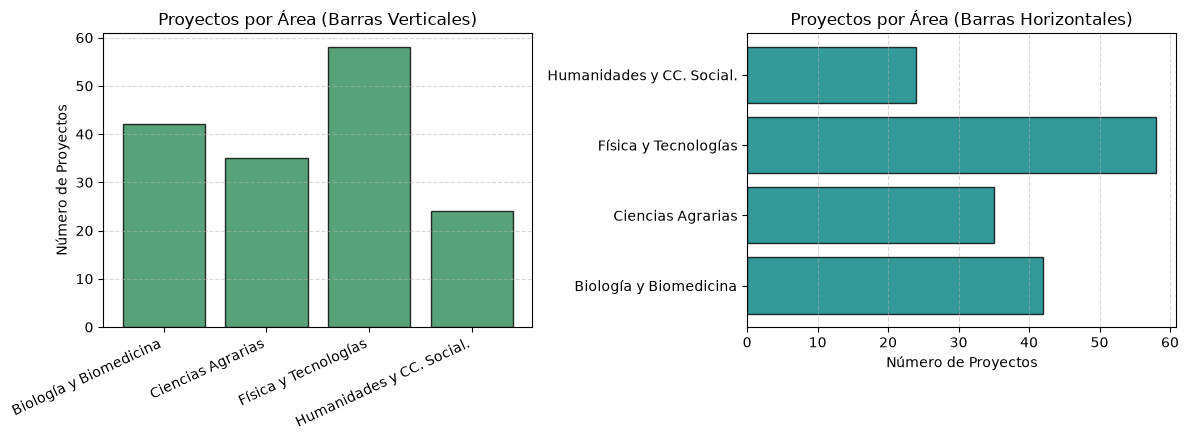

****************************************************************************************************


In [14]:
# 4.2. Gráfico de Barras Categórico (Horizontal y Vertical)
areas_csic = ['Biología y Biomedicina', 'Ciencias Agrarias', 'Física y Tecnologías', 'Humanidades y CC. Social.']
proyectos = [42, 35, 58, 24]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Barras verticales
ax1.bar(areas_csic, proyectos, color='seagreen', edgecolor='black', alpha=0.8)
ax1.set_title("Proyectos por Área (Barras Verticales)")
ax1.set_ylabel("Número de Proyectos")
ax1.set_xticklabels(areas_csic, rotation=25, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# Barras horizontales
ax2.barh(areas_csic, proyectos, color='teal', edgecolor='black', alpha=0.8)
ax2.set_title("Proyectos por Área (Barras Horizontales)")
ax2.set_xlabel("Número de Proyectos")
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
linea()

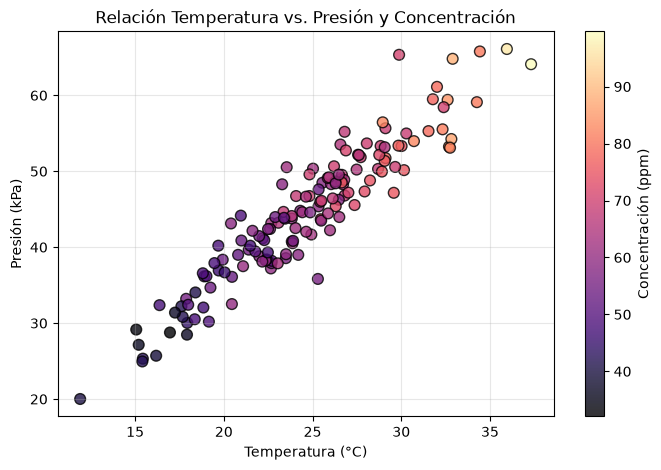

****************************************************************************************************


In [17]:
# 4.3. Gráfico de Dispersión (Scatter Plot con Colormap)
np.random.seed(42)
n_puntos = 150
temp = np.random.normal(25, 5, n_puntos)
presion = temp * 1.8 + np.random.normal(0, 3, n_puntos)
concentracion = temp * 2.5 + np.random.normal(0, 5, n_puntos)

fig, ax = plt.subplots(figsize=(8, 5))
cmaps=("magma","cool","hot","viridis","jet")
scatter = ax.scatter(temp, presion, c=concentracion, cmap=cmaps[0], s=60, alpha=0.8, edgecolors='black')

ax.set_title("Relación Temperatura vs. Presión y Concentración")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Presión (kPa)")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Concentración (ppm)")
ax.grid(True, alpha=0.3)

plt.show()
linea()


### 💡 Conceptos Clave de Distribución Estadística: Curtosis y Boxplot

#### 1. ¿Qué es la Curtosis (Kurtosis)?
La **curtosis** es una medida estadística que describe el **apuntamiento** de una distribución y el **grosor de sus colas** en comparación con una distribución normal (campana de Gauss):

- **Mesocúrtica ($\text{Curtosis} \approx 0$):** Distribución normal estándar.
- **Leptocúrtica ($\text{Curtosis} > 0$):** Distribución muy apuntada en el centro y con colas "pesadas" (mayor presencia de valores extremos o atípicos).
- **Platicúrtica ($\text{Curtosis} < 0$):** Distribución más aplanada y con colas ligeras (datos más homogéneamente dispersos).

---

#### 2. ¿Qué explica un Diagrama de Caja (*Boxplot*)?
El **boxplot** resume la distribución de una variable continua mediante **5 números clave**:

1. **Línea central de la caja:** La **Mediana** ($Q_2$ o percentil 50%).
2. **Límites de la caja:** El **Primer Cuartil** ($Q_1$ o percentil 25%) y el **Tercer Cuartil** ($Q_3$ o percentil 75%).
3. **Rango Intercuartílico ($\text{IQR}$):** La altura de la caja ($\text{IQR} = Q_3 - Q_1$), que contiene el **50% central de los datos**.
4. **Bigotes (*Whiskers*):** Se extienden hasta el dato más lejano a una distancia máxima de $1.5 \times \text{IQR}$ desde los bordes de la caja.
5. **Puntos aislados (*Outliers*):** Observaciones atípicas situadas más allá de los bigotes.


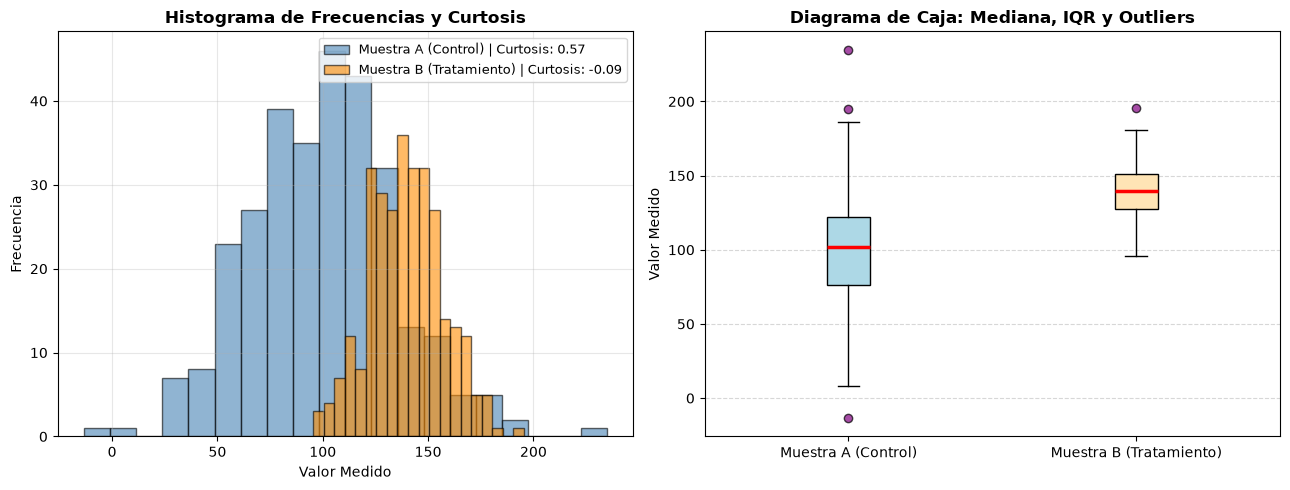

****************************************************************************************************


In [18]:
# 4.4. Histograma con Curtosis y Diagrama de Caja (Boxplot)
from scipy.stats import kurtosis

# Generación de muestras aleatorias
np.random.seed(42)
muestra_a = np.random.normal(100, 35, 300)
muestra_b = np.random.normal(140, 18, 300)

# Calcular curtosis para cada muestra (Fisher=True devuelve 0 para la distribución normal)
kurt_a = kurtosis(muestra_a)
kurt_b = kurtosis(muestra_b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------------------------------------------
# 1. Histograma Superpuesto con métrica de Curtosis
# -------------------------------------------------------------
ax1.hist(muestra_a, bins=20, alpha=0.6, label=f'Muestra A (Control) | Curtosis: {kurt_a:.2f}', color='steelblue', edgecolor='black')
ax1.hist(muestra_b, bins=20, alpha=0.6, label=f'Muestra B (Tratamiento) | Curtosis: {kurt_b:.2f}', color='darkorange', edgecolor='black')

ax1.set_title("Histograma de Frecuencias y Curtosis", fontweight='bold')
ax1.set_xlabel("Valor Medido")
ax1.set_ylabel("Frecuencia")
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# -------------------------------------------------------------
# 2. Diagrama de Caja (Boxplot)
# -------------------------------------------------------------
bp = ax2.boxplot([muestra_a, muestra_b], tick_labels=['Muestra A (Control)', 'Muestra B (Tratamiento)'], patch_artist=True,
                 medianprops=dict(color='red', linewidth=2.5),
                 flierprops=dict(marker='o', markerfacecolor='purple', markersize=6, alpha=0.7))

# Personalizar colores de las cajas
colores = ['lightblue', 'moccasin']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

ax2.set_title("Diagrama de Caja: Mediana, IQR y Outliers", fontweight='bold')
ax2.set_ylabel("Valor Medido")
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
linea()


## 5. Visualización Directa desde DataFrames de Pandas

Pandas integra Matplotlib directamente a través del método `.plot()`. Esto permite explorar y visualizar DataFrames con una sintaxis limpia e intuitiva.

Cargaremos el dataset curado de **Digital.CSIC** (`digital_csic_curated.csv`) para analizar visualmente la producción científica del CSIC.


In [19]:
# Cargar el dataset curado de Digital.CSIC
dataset_path = os.path.join(datasets_dir, "digital_csic_curated.csv")
df_csic = pd.read_csv(dataset_path)
print(f"Dataset cargado correctamente. Dimensiones: {df_csic.shape}")
print("Primeras 3 filas:")
print(df_csic[['handle', 'year', 'journal']].head(3) if 'handle' in df_csic.columns else df_csic.head(3))
linea()


Dataset cargado correctamente. Dimensiones: (45, 8)
Primeras 3 filas:
         handle  year                                            journal
0  10261/398193  2025                                  John Wiley & Sons
1  10261/158705  2018                                     Inter Research
2  10261/329833  2023  CSIC - Unidad de Recursos de Información Cient...
****************************************************************************************************


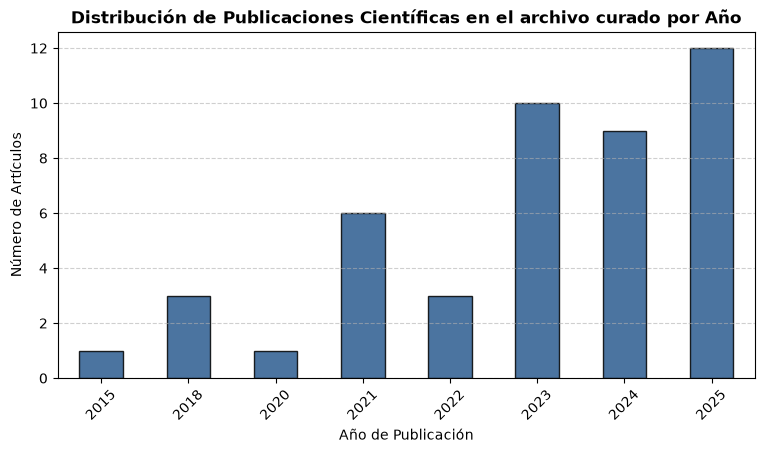

****************************************************************************************************


In [20]:
# Gráfico 1: Producción Científica por Año (Serie de Barras desde Pandas)
publicaciones_por_año = df_csic[df_csic['year'] > 2000]['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
publicaciones_por_año.plot(kind='bar', ax=ax, color='#2b5c8f', edgecolor='black', alpha=0.85)

ax.set_title("Distribución de Publicaciones Científicas en el archivo curado por Año", fontsize=12, fontweight='bold')
ax.set_xlabel("Año de Publicación")
ax.set_ylabel("Número de Artículos")
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.show()
linea()


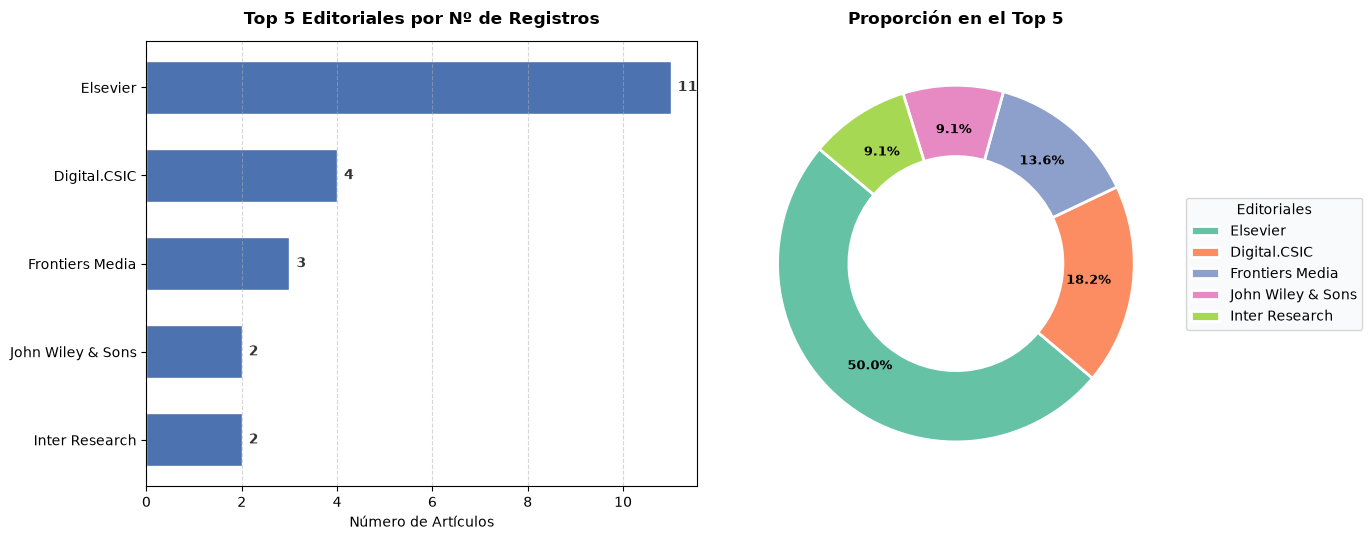

****************************************************************************************************


In [21]:
# Gráfico 2: Top 5 Editoriales / Fuentes en Digital.CSIC (Diseño Profesional)
top_revistas = df_csic['journal'].value_counts().head(5)

# 1. Truncar nombres de revistas muy largos para evitar solapamientos
nombres_cortos = [name[:25] + '...' if len(name) > 25 else name for name in top_revistas.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# -------------------------------------------------------------
# 1. Barras Horizontales con Etiquetas de Valor
# -------------------------------------------------------------
barras = ax1.barh(nombres_cortos, top_revistas.values, color='#4c72b0', edgecolor='white', height=0.6)
ax1.set_title("Top 5 Editoriales por Nº de Registros", fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Número de Artículos", fontsize=10)
ax1.invert_yaxis()  # Poner el Top 1 en la parte superior
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir el número exacto al final de cada barra
ax1.bar_label(barras, padding=5, fontweight='bold', color='#333333')

# -------------------------------------------------------------
# 2. Gráfico de Dona (Donut Chart) con Leyenda Externa
# -------------------------------------------------------------
colores_dona = plt.cm.Set2.colors[:5]

wedges, texts, autotexts = ax2.pie(
    top_revistas.values,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=140,
    colors=colores_dona,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), # Diseño tipo Dona
    textprops=dict(weight='bold', color='black', fontsize=9)
)

ax2.set_title("Proporción en el Top 5", fontsize=12, fontweight='bold', pad=12)

# Colocar leyenda limpia a la derecha fuera del gráfico
ax2.legend(
    wedges,
    nombres_cortos,
    title="Editoriales",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=True,
    facecolor='#f8f9fa'
)

plt.tight_layout()
plt.show()
linea()


## 6. Composición de Subplots y Paneles Multi-Figura

En artículos e informes científicos es habitual combinar múltiples gráficos en un **único panel multipanel** para comparar métricas o presentar varios aspectos de una misma investigación.

### Métodos Principales:
1. **`plt.subplots(nrows, ncols)`:** Matriz regular de gráficos.
2. **`subplot2grid((rows, cols), (loc_row, loc_col), rowspan, colspan)`:** Diseño asimétrico donde una figura ocupa múltiples filas o columnas.


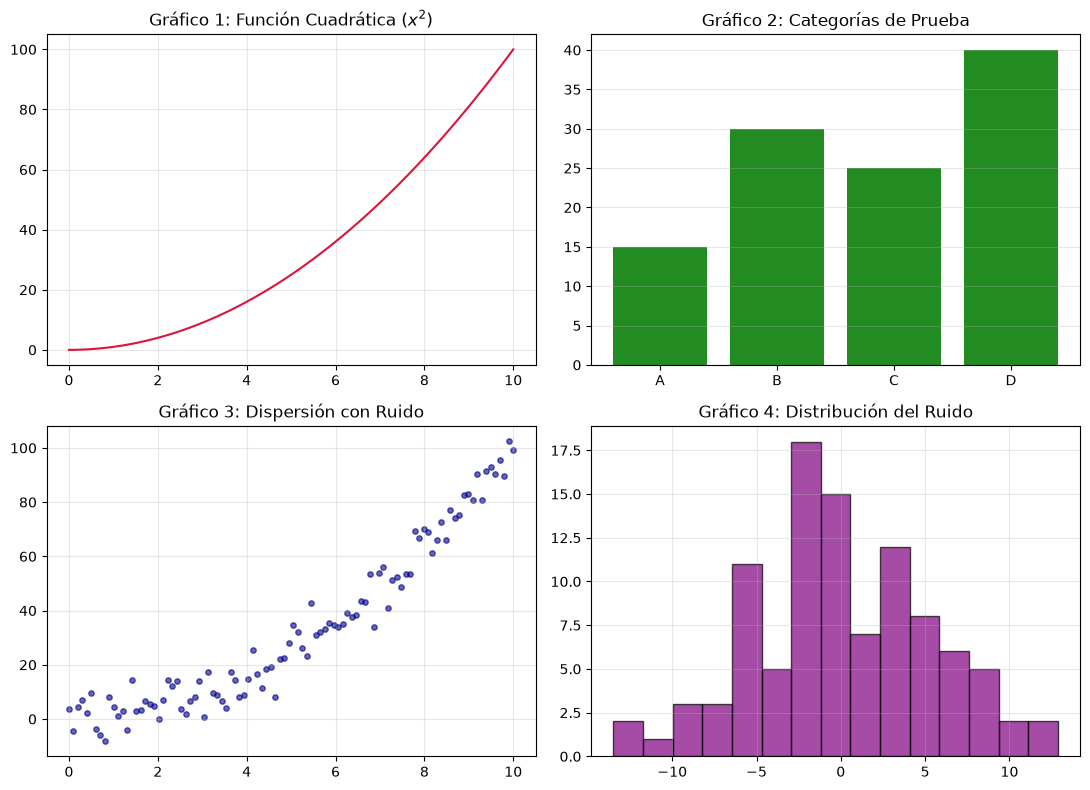

****************************************************************************************************


In [22]:
# Panel Regular de 2x2 Gráficos (Matriz de Subplots)
x_grid = np.linspace(0, 10, 100)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Subplot 0,0: Líneas
axes[0, 0].plot(x_grid, x_grid**2, color='crimson')
axes[0, 0].set_title("Gráfico 1: Función Cuadrática ($x^2$)")
axes[0, 0].grid(True, alpha=0.3)

# Subplot 0,1: Barras
axes[0, 1].bar(['A', 'B', 'C', 'D'], [15, 30, 25, 40], color='forestgreen')
axes[0, 1].set_title("Gráfico 2: Categorías de Prueba")
axes[0, 1].grid(axis='y', alpha=0.3)

# Subplot 1,0: Dispersión
ruido_s = np.random.normal(0, 5, size=len(x_grid))
axes[1, 0].scatter(x_grid, x_grid**2 + ruido_s, color='darkblue', s=15, alpha=0.6)
axes[1, 0].set_title("Gráfico 3: Dispersión con Ruido")
axes[1, 0].grid(True, alpha=0.3)

# Subplot 1,1: Histograma
axes[1, 1].hist(ruido_s, bins=15, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title("Gráfico 4: Distribución del Ruido")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
linea()


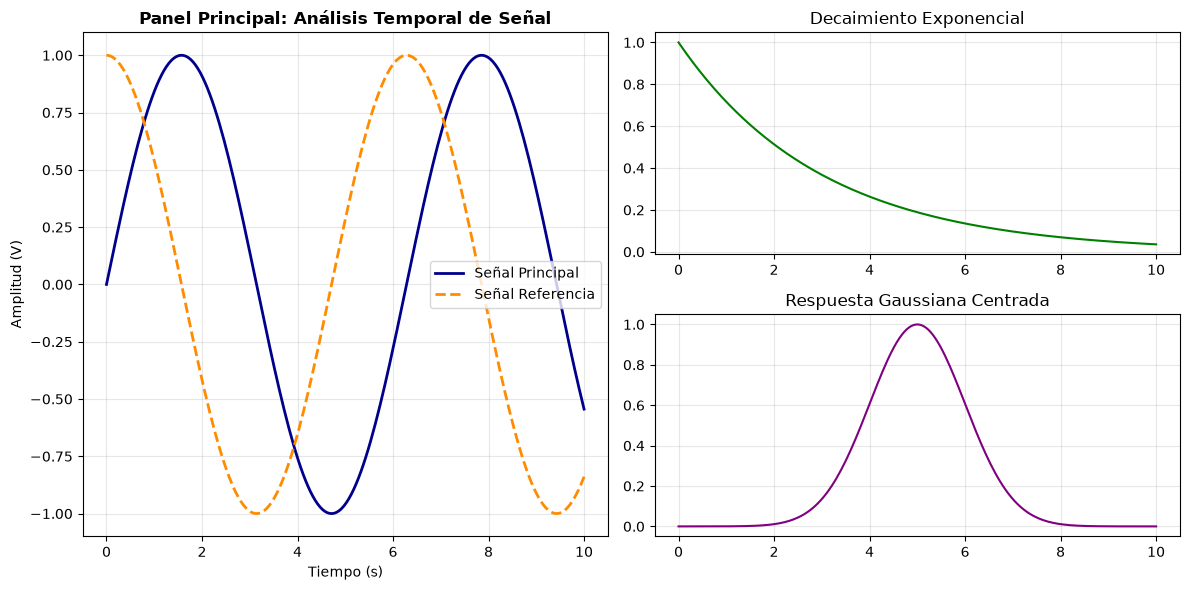

****************************************************************************************************


In [23]:
# Layout Asimétrico Avanzado con subplot2grid
fig = plt.figure(figsize=(12, 6))

# Panel Principal (ocupa 2 filas en la columna izquierda)
ax_main = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
ax_top_right = plt.subplot2grid((2, 2), (0, 1))
ax_bot_right = plt.subplot2grid((2, 2), (1, 1))

# Gráfico principal (Izquierda)
x_time = np.linspace(0, 10, 200)
ax_main.plot(x_time, np.sin(x_time), label="Señal Principal", color="darkblue", linewidth=2)
ax_main.plot(x_time, np.cos(x_time), label="Señal Referencia", color="darkorange", linestyle="--", linewidth=2)
ax_main.set_title("Panel Principal: Análisis Temporal de Señal", fontweight='bold')
ax_main.set_xlabel("Tiempo (s)")
ax_main.set_ylabel("Amplitud (V)")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

# Gráfico superior derecho
ax_top_right.plot(x_time, np.exp(-x_time / 3), color="green")
ax_top_right.set_title("Decaimiento Exponencial")
ax_top_right.grid(True, alpha=0.3)

# Gráfico inferior derecho
ax_bot_right.plot(x_time, np.exp(-((x_time - 5)**2) / 2), color="purple")
ax_bot_right.set_title("Respuesta Gaussiana Centrada")
ax_bot_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
linea()


## 7. Exportación de Figuras de Calidad para Publicación Científica

En la práctica de la Ciencia Abierta, es fundamental guardar las figuras en **resolución suficiente** y formatos adecuados según el destino:

- **Formatos Rasterizados (`PNG`, `JPEG`, `TIFF`):** Compuestos por píxeles. Útiles para presentaciones, páginas web o artículos. Se debe especificar `dpi=300` o superior.
- **Formatos Vectoriales (`PDF`, `SVG`, `EPS`):** Escalables sin pérdida de resolución. Formato recomendado por la mayoría de las revistas científicas de impacto.
- **Ajuste de Margen (`bbox_inches='tight'`):** Evita que los títulos o etiquetas de los ejes queden cortados en la imagen guardada.


Figura PNG (300 DPI) guardada en: '../DATASETS/figura_publicacion_csic.png'
Figura PDF (Vectorial) guardada en: '../DATASETS/figura_publicacion_csic.pdf'


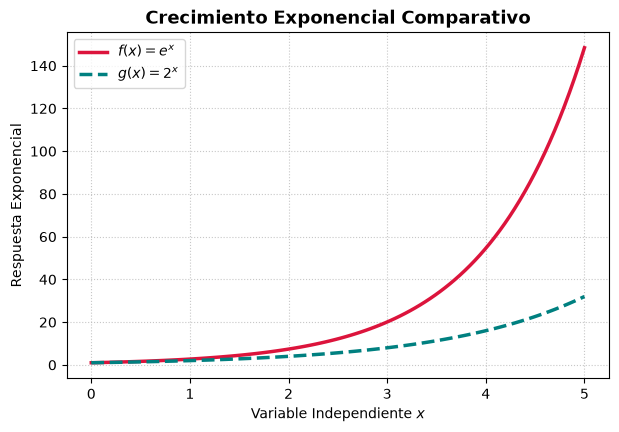

****************************************************************************************************


In [24]:
# Crear una figura de alta calidad y exportarla programáticamente
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)

x_exp = np.linspace(0, 5, 100)
ax.plot(x_exp, np.exp(x_exp), color='crimson', linewidth=2.5, label=r'$f(x) = e^x$')
ax.plot(x_exp, 2**x_exp, color='teal', linestyle='--', linewidth=2.5, label=r'$g(x) = 2^x$')

ax.set_title("Crecimiento Exponencial Comparativo", fontsize=13, fontweight='bold')
ax.set_xlabel("Variable Independiente $x$")
ax.set_ylabel("Respuesta Exponencial")
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.7)

# Definir la ruta de exportación dentro de DATASETS o la carpeta del cuaderno
output_png = os.path.join(datasets_dir, "figura_publicacion_csic.png")
output_pdf = os.path.join(datasets_dir, "figura_publicacion_csic.pdf")

# Guardar en alta resolución (PNG 300 DPI) y en formato vectorial (PDF)
fig.savefig(output_png, dpi=300, bbox_inches='tight')
fig.savefig(output_pdf, bbox_inches='tight')

print(f"Figura PNG (300 DPI) guardada en: '{output_png}'")
print(f"Figura PDF (Vectorial) guardada en: '{output_pdf}'")

plt.show()
linea()


## 8. Recursos Adicionales y Apoyo con Modelos de Lenguaje (IA)

Matplotlib posee una inmensa variedad de opciones gráficas y estilos visuales.

### Enlaces de Referencia Oficial:
- 📊 **Galería de Tipos de Gráficos:** [https://matplotlib.org/stable/plot_types/index.html](https://matplotlib.org/stable/plot_types/index.html)
- 📚 **Tutoriales Oficiales:** [https://matplotlib.org/stable/tutorials/index.html](https://matplotlib.org/stable/tutorials/index.html)
- 📖 **Documentación de la API:** [https://matplotlib.org/stable/api/index.html](https://matplotlib.org/stable/api/index.html)

---

### 💡 Apoyo con Asistentes de IA (ChatGPT, Gemini, Copilot):
Los Modelos de Lenguaje son excelentes aliados para acelerar la personalización de tus figuras en Python:
- **Recordar sintaxis específica:** *(Ej. "¿Cómo cambio la orientación del texto de los ticks en Matplotlib?")*
- **Personalización de estilos:** *(Ej. "Dame un mapa de colores divergente adecuado para daltonismo").*
- **Ajustes de diseño:** *(Ej. "¿Cómo agrego dos ejes Y independientes con distinta escala?").*


## 9. Ejercicios Prácticos y Autoevaluación

### Ejercicio 1: Subplot Comparativo
Crea una figura con **2 gráficos dispuestos en una sola fila (`1, 2`)**:
1. El primer gráfico debe mostrar un **gráfico de dispersión** de 100 puntos aleatorios.
2. El segundo gráfico debe mostrar el **histograma** de esos mismos puntos con 15 barras (`bins=15`) y color `seagreen`.


In [ ]:
# Solución Ejercicio 1
datos_ej1 = np.random.normal(loc=50, scale=10, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1. Scatter plot
ax1.scatter(range(len(datos_ej1)), datos_ej1, color='navy', alpha=0.7)
ax1.set_title("Dispersión de la Muestra")
ax1.set_xlabel("Índice de la Observación")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# 2. Histograma
ax2.hist(datos_ej1, bins=15, color='seagreen', edgecolor='black', alpha=0.8)
ax2.set_title("Histograma de Frecuencias")
ax2.set_xlabel("Valor")
ax2.set_ylabel("Frecuencia")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
linea()


### Ejercicio 2: Gráfico de Barras con Datos de Pandas
A partir del DataFrame `df_csic`, calcula la cantidad de artículos publicados por década (o antes/después del año 2020) y representa los resultados mediante un **gráfico de barras horizontales** personalizado con títulos y cuadrícula.


In [ ]:
# Solución Ejercicio 2
# Agrupar por condición temporal
df_csic['periodo'] = np.where(df_csic['year'] >= 2020, '2020 o Posterior', 'Anterior a 2020')
periodos = df_csic['periodo'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
periodos.plot(kind='barh', ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black', alpha=0.85)

ax.set_title("Comparativa de Publicaciones: Antes vs. A partir de 2020", fontweight='bold')
ax.set_xlabel("Número de Artículos")
ax.set_ylabel("Periodo")
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
linea()


---

### 🎬 Videopodcast Resumen del Módulo (08)

<div align="center">
  <video width="100%" style="max-width: 800px; border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.15);" controls>
    <source src="../assets/VIDEOPODCASTS/modulo_08.mp4" type="video/mp4">
    Tu navegador o entorno de Jupyter no soporta reproducción directa de vídeos HTML5.
  </video>
</div>

---

### 📝 Cuestionario de Auto-evaluación y Participación

¡Pon a prueba los conocimientos adquiridos en este módulo! Completa este breve cuestionario interactivo de 5 minutos en Google Forms:

👉 **[Cuestionario Módulo 08 en Google Forms](https://docs.google.com/forms/d/e/1FAIpQLScaVIrAoc1saljXMwokAdVcdNiyMGAB9eZtpUCjqD0VrqtZSg/viewform?usp=sharing&ouid=101670006760862697598)**

---

### 🎧 Tutor Virtual & Libreta de Estudio (Google NotebookLM)

¿Quieres escuchar el resumen conversacional en audio de este módulo o resolver dudas con el tutor virtual del curso?

👉 **[Acceder al Espacio de Estudio Interactivo en NotebookLM](https://notebook.google.com/notebook/d76ad7db-e258-4386-a050-9c15d29d8fb2/artifact/08aec159-c0c7-44df-90d1-2d29666a79f1)**

---
